# V2 — Data-Representation Metrics

Pointwise scores like RMSE rank predictions by their *amplitude* of error, but they cannot tell apart **a displaced field** from **a smeared field**. V2 metrics — structural and probabilistic — recover those distinctions.

This notebook walks through the diagnostic on a **real Gulf Stream SSH snapshot** from GLORYS12. We construct two controlled "predictions" from the same truth field:

1. **Displaced** — the GLORYS field rolled +12 longitude cells (≈ 1° east, ≈ 90 km at 37°N). Same structure, wrong location.
2. **Smeared** — the GLORYS field gaussian-smoothed (σ = 3 cells ≈ 28 km). Right location, lost sub-mesoscale gradients.

Pointwise metrics give inconsistent verdicts; structural metrics characterise the *type* of error, and `PhaseShiftError` recovers the displacement vector. A 30-member synthetic ensemble around the truth exercises the probabilistic operators. `MaskedMetric` restricts a pointwise score to the Gulf Stream front. Bonus sections show the same metrics composed via `Sequential` (preprocessing) and `Graph` (full DAG).

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from scipy.ndimage import gaussian_filter

from xr_toolz import Graph, Input, Sequential, Signature
from xr_toolz.geo.operators import RemoveMean, SelectVariables, ValidateCoords
from xr_toolz.metrics import (
    CRPS,
    MAE,
    RMSE,
    SSIM,
    Correlation,
    EnsembleCoverage,
    GradientDifference,
    MaskedMetric,
    PhaseShiftError,
    RankHistogram,
    SpreadSkillRatio,
)

rng = np.random.default_rng(0)
GLORYS_CACHE = Path("../../.cache/glorys12_gulfstream_2023-06.nc")

## 1 — Load real Gulf Stream SSH from GLORYS12

We take a single day (2023-06-01) from the cached GLORYS12 reanalysis: 1/12° resolution over `[-70, -50] × [30, 45]`. The Gulf Stream front shows up clearly as the steep gradient between cool slope water (low SSH) and the subtropical gyre (high SSH). We fill the small land-NaN footprint with the field mean for the FFT-based metrics; the basin is ~98 % ocean here.

**Cache file**. The notebook expects `.cache/glorys12_gulfstream_2023-06.nc` (gitignored, ~5 MB). It is **the same cache** used by the V1 *Scales of Evaluation* notebook — see § 8 of [`validation_v1_scales.ipynb`](validation_v1_scales.ipynb) for the `copernicusmarine` rebuild snippet (requires CMEMS credentials in `~/.copernicusmarine/`). Reproduced here for convenience:

```python
import copernicusmarine as cm
bbox = dict(
    minimum_longitude=-70.0, maximum_longitude=-50.0,
    minimum_latitude=30.0,   maximum_latitude=45.0,
)
window = dict(start_datetime="2023-06-01", end_datetime="2023-06-15")
glorys = cm.open_dataset(
    dataset_id="cmems_mod_glo_phy_my_0.083deg_P1D-m",
    variables=["zos"], **bbox, **window,
).load()
glorys.to_netcdf(".cache/glorys12_gulfstream_2023-06.nc")
```

In [2]:
glorys = xr.open_dataset(GLORYS_CACHE).rename({"latitude": "lat", "longitude": "lon"})
glorys = glorys.assign_coords(
    lat=("lat", np.linspace(float(glorys.lat[0]), float(glorys.lat[-1]), glorys.sizes["lat"]),
         {"units": "degrees_north"}),
    lon=("lon", np.linspace(float(glorys.lon[0]), float(glorys.lon[-1]), glorys.sizes["lon"]),
         {"units": "degrees_east"}),
)
zos_raw = glorys["zos"].isel(time=0)
fill = float(zos_raw.mean(skipna=True))
zos_truth = zos_raw.fillna(fill)

ds_truth = xr.Dataset({"ssh": zos_truth.rename("ssh")})

## 2 — Two predictions

Both predictions are deterministic edits of the same truth field, so the pedagogical contrast is clean. Real models err in messier ways — but synthetic *displacement* and *smearing* are the two failure modes that V2 metrics are designed to separate.

In [3]:
shift_pixels = 12  # ≈ 1° in longitude on the 1/12° grid

ds_displaced = ds_truth.copy()
ds_displaced["ssh"] = (
    ("lat", "lon"),
    np.roll(zos_truth.values, shift=shift_pixels, axis=zos_truth.get_axis_num("lon")),
)

ds_smeared = ds_truth.copy()
ds_smeared["ssh"] = (
    ("lat", "lon"),
    gaussian_filter(zos_truth.values, sigma=3.0),
)

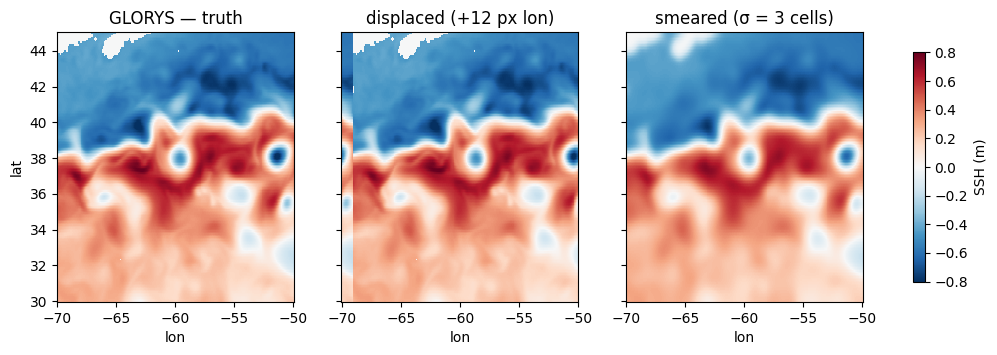

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
panels = [
    (ds_truth["ssh"], "GLORYS — truth"),
    (ds_displaced["ssh"], "displaced (+12 px lon)"),
    (ds_smeared["ssh"], "smeared (σ = 3 cells)"),
]
for ax, (da, title) in zip(axes, panels, strict=True):
    im = ax.pcolormesh(da["lon"], da["lat"], da.values, vmin=-0.8, vmax=0.8, cmap="RdBu_r")
    ax.set_title(title)
    ax.set_xlabel("lon")
axes[0].set_ylabel("lat")
fig.colorbar(im, ax=axes, shrink=0.85, label="SSH (m)")
plt.show()

## 3 — Pointwise metrics give inconsistent verdicts

Each pointwise score tells a different story, and none of them diagnose *why* a prediction is wrong. The Gulf Stream's sharp front is exactly the kind of structure where displacement creates large pointwise error and smoothing flattens gradients — both look bad, in different ways.

In [5]:
dims = ("lat", "lon")
pointwise_ops = {
    "RMSE": RMSE("ssh", dims=dims),
    "MAE": MAE("ssh", dims=dims),
    "Correlation": Correlation("ssh", dims=dims),
}


def score(op, ds_pred, ds_ref):
    out = op(ds_pred, ds_ref)
    arr = out["ssh"] if isinstance(out, xr.Dataset) else out
    return float(arr.values)


pointwise_table = pd.DataFrame(
    {
        name: {
            "displaced": score(op, ds_displaced, ds_truth),
            "smeared": score(op, ds_smeared, ds_truth),
        }
        for name, op in pointwise_ops.items()
    }
)
pointwise_table

,RMSE,MAE,Correlation
displaced,0.193408,0.118803,0.895186
smeared,0.035358,0.020908,0.996732


## 4 — Structural metrics characterise the *type* of error

`SSIM` rewards local structural similarity — the smeared field keeps the front's shape, so SSIM rates it closer to truth than the displaced field. `GradientDifference` penalises mismatched spatial gradients; smoothing flattens the Gulf Stream front, so its gradient error is large where the front used to be, while displacement creates gradient errors at the leading and trailing edges of the shift. `PhaseShiftError` is the diagnostic: it **recovers the displacement vector** for the displaced case (a +12-pixel shift in longitude on the 1/12° grid → +1°) and a near-zero residual once that shift is undone.

In [6]:
ssim_op = SSIM("ssh", dims=dims)
gd_op = GradientDifference("ssh", dims=dims)
pse_op = PhaseShiftError("ssh", dims=dims)

structural_rows = []
for label, ds_pred in [("displaced", ds_displaced), ("smeared", ds_smeared)]:
    pse = pse_op(ds_pred, ds_truth)
    structural_rows.append(
        {
            "case": label,
            "SSIM": float(ssim_op(ds_pred, ds_truth).values),
            "GradientDifference": float(gd_op(ds_pred, ds_truth).values),
            "PSE shift_lat (px)": int(pse["shift_lat"].values),
            "PSE shift_lon (px)": int(pse["shift_lon"].values),
            "PSE residual RMSE": float(pse["residual_rmse"].values),
        }
    )
structural_table = pd.DataFrame(structural_rows).set_index("case")
structural_table

,SSIM,GradientDifference,PSE shift_lat (px),PSE shift_lon (px),PSE residual RMSE
case,,,,,
displaced,0.554309,0.595460,0,12,0.000000
smeared,0.937507,0.264293,0,0,0.035358


`PhaseShiftError` reads the displacement off the data exactly: +12 pixels in longitude, ~0 in latitude, and the residual after undoing the shift is at floating-point noise level for the displaced case. For the smeared case, no shift removes the error, so the recovered shift is zero and the residual ≈ the smearing amplitude.

## 5 — Probabilistic metrics on a synthetic ensemble

We build a 30-member ensemble centred on the GLORYS truth, perturbed with i.i.d. noise of σ = 5 cm. The probabilistic operators consume an `ensemble_dim` (default `"member"`).

In [7]:
n_members = 30
noise_amp = 0.05  # m
truth_arr = zos_truth.values
ensemble = truth_arr[None, ...] + noise_amp * rng.standard_normal((n_members, *truth_arr.shape))
ds_ensemble = xr.Dataset(
    {"ssh": (("member", "lat", "lon"), ensemble)},
    coords={
        "lat": ds_truth["lat"],
        "lon": ds_truth["lon"],
        "member": np.arange(n_members),
    },
)

prob_ops = {
    "SpreadSkillRatio": SpreadSkillRatio("ssh", dims=dims),
    "CRPS": CRPS("ssh", dims=dims),
    "EnsembleCoverage(5–95%)": EnsembleCoverage("ssh", q=(0.05, 0.95)),
}

prob_results = {
    name: float(
        (op(ds_ensemble, ds_truth)["ssh"]
         if isinstance(op(ds_ensemble, ds_truth), xr.Dataset)
         else op(ds_ensemble, ds_truth)).values
    )
    for name, op in prob_ops.items()
}
pd.Series(prob_results, name="value").to_frame()

,value
SpreadSkillRatio,5.477868
CRPS,0.012622
EnsembleCoverage(5–95%),1.000000


A well-tuned ensemble has `SpreadSkillRatio ≈ 1` (under-spread < 1, over-spread > 1) and `EnsembleCoverage ≈ 0.9` for a 5–95% interval. Our toy ensemble is centred on truth so the ensemble-mean error is tiny while the spread is finite — `SpreadSkillRatio` ≫ 1 and `EnsembleCoverage` saturates at 1.0. That is exactly what those diagnostics are designed to flag: the ensemble is **over-dispersive**.

`RankHistogram` returns one bin per rank; a flat histogram indicates a calibrated ensemble. An over-dispersive ensemble produces a bell-shaped histogram peaking at mid ranks (truth lands in the middle more often than the tails).

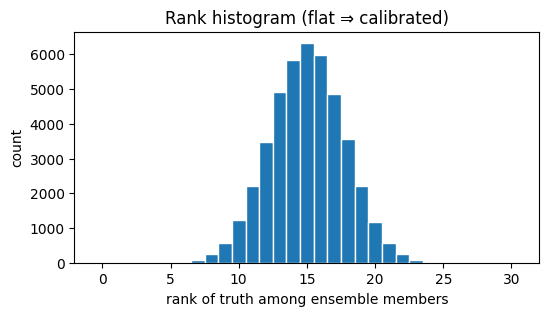

In [8]:
rh = RankHistogram("ssh")(ds_ensemble, ds_truth)
rh_counts = rh["rank_count"]

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(rh_counts["rank"].values, rh_counts.values, width=1.0, edgecolor="white")
ax.set_xlabel("rank of truth among ensemble members")
ax.set_ylabel("count")
ax.set_title("Rank histogram (flat ⇒ calibrated)")
plt.show()

## 6 — `MaskedMetric` restricts scoring to the Gulf Stream front

Different parts of the basin have very different SSH variance. To answer *"is my model accurate where the action is?"*, wrap any pointwise operator in `MaskedMetric` with a boolean mask covering the high-variance Gulf Stream front (here defined as |zos| > 0.4 m).

In [9]:
front_mask = xr.DataArray(
    np.abs(zos_truth.values) > 0.4,
    dims=("lat", "lon"),
    coords={"lat": ds_truth["lat"], "lon": ds_truth["lon"]},
)

masked_rmse = MaskedMetric(RMSE("ssh", dims=dims), mask=front_mask)
masked_table = pd.DataFrame(
    {
        "RMSE (full domain)": {
            "displaced": score(RMSE("ssh", dims=dims), ds_displaced, ds_truth),
            "smeared": score(RMSE("ssh", dims=dims), ds_smeared, ds_truth),
        },
        "RMSE (Gulf Stream front)": {
            "displaced": score(masked_rmse, ds_displaced, ds_truth),
            "smeared": score(masked_rmse, ds_smeared, ds_truth),
        },
    }
)
masked_table

,RMSE (full domain),RMSE (Gulf Stream front)
displaced,0.193408,0.179864
smeared,0.035358,0.035936


The front-only mask gives a different number than the basin-wide score — useful when you care specifically about model fidelity in the high-energy region. Here both error magnitudes are similar (the front dominates the basin-wide variance anyway), but on a real model with localised biases the masked score can move sharply away from the basin-wide one.

## 7 — Side-by-side summary

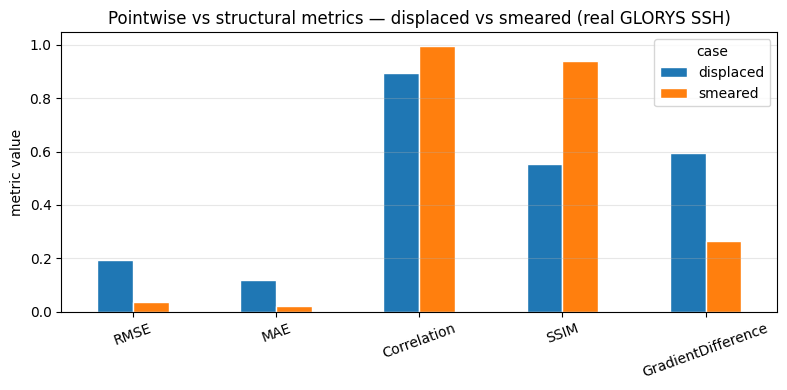

In [10]:
summary = pd.concat(
    [pointwise_table, structural_table[["SSIM", "GradientDifference"]]], axis=1
)

fig, ax = plt.subplots(figsize=(8, 4))
summary.T.plot.bar(ax=ax, rot=20, edgecolor="white")
ax.set_ylabel("metric value")
ax.set_title("Pointwise vs structural metrics — displaced vs smeared (real GLORYS SSH)")
ax.legend(title="case")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 8 — Bonus: a `Sequential` preprocessing pipeline

`Sequential` chains *single-input* operators, so it's the natural fit for the **preprocessing** half of a validation pipeline — variable selection, coord validation, mean removal, regridding — applied identically to prediction and reference before scoring. Building one `Sequential` and reusing it on both inputs guarantees the two datasets are prepared the same way; the metrics then run on the cleaned outputs.

In [11]:
preprocess = Sequential(
    [
        SelectVariables(["ssh"]),
        ValidateCoords(),
        RemoveMean(("lat", "lon")),
    ]
)
print(preprocess.describe())
print()
# Per-step shape inference. The pipeline runs over an ssh DataArray
# inside the Dataset, so we feed its sizes as the input signature.
input_signature = Signature(
    dict(ds_truth.sizes), dtype=str(ds_truth["ssh"].dtype),
)
print(preprocess.summary(input_signature))

Sequential (3 ops)
├── SelectVariables(variables=['ssh'])
├── ValidateCoords()
└── RemoveMean(dims=['lat', 'lon'])

Sequential (3 ops)
Step  Operator                            Input Signature                    Output Signature                 
----  ----------------------------------  ---------------------------------  ---------------------------------
0     SelectVariables(variables=['ssh'])  (lat=181, lon=241); dtype=float64  (lat=181, lon=241); dtype=float64
1     ValidateCoords()                    (lat=181, lon=241); dtype=float64  (lat=181, lon=241); dtype=float64
2     RemoveMean(dims=['lat', 'lon'])     (lat=181, lon=241); dtype=float64  (lat=181, lon=241); dtype=float64


In [12]:
metric_ops = {
    "rmse": RMSE("ssh", dims=dims),
    "correlation": Correlation("ssh", dims=dims),
    "ssim": SSIM("ssh", dims=dims),
    "gradient_difference": GradientDifference("ssh", dims=dims),
    "phase_shift_residual": PhaseShiftError("ssh", dims=dims),
}


def run_scorecard(ds_pred, ds_ref):
    row = {}
    for name, op in metric_ops.items():
        out = op(ds_pred, ds_ref)
        if name == "phase_shift_residual":
            row[name] = float(out["residual_rmse"].values)
        else:
            arr = out["ssh"] if isinstance(out, xr.Dataset) else out
            row[name] = float(arr.values)
    return row


ds_truth_pp = preprocess(ds_truth)
ds_displaced_pp = preprocess(ds_displaced)
ds_smeared_pp = preprocess(ds_smeared)

sequential_table = pd.DataFrame(
    {
        "displaced": run_scorecard(ds_displaced_pp, ds_truth_pp),
        "smeared": run_scorecard(ds_smeared_pp, ds_truth_pp),
    }
).T
sequential_table

,rmse,correlation,ssim,gradient_difference,phase_shift_residual
displaced,0.193408,0.895186,0.555171,0.595460,0.000000
smeared,0.035358,0.996732,0.937183,0.264293,0.035358


Removing the basin-mean before scoring shifts every metric: the absolute amplitude bias gets re-distributed, the displaced field's gradient information is preserved, and `PhaseShiftError` still recovers the displacement on the de-meaned signal. Whether you want this pre-step depends on your validation question — but with `Sequential` it's a one-line decision applied symmetrically.

## 9 — Bonus: full `Graph` — preprocessing **and** metrics in one DAG

`Graph` generalises `Sequential` to any DAG, so we can wire two `Input`s (`prediction`, `reference`), the same `Sequential` preprocessing applied to each, and one terminal `Node` per metric — **a single call emits every score at once**, with the preprocessing baked in. This is the wiring you'd reuse in CI, or hand off to V6 panels for plotting.

In [13]:
pred_in = Input(name="prediction")
ref_in = Input(name="reference")

pred_pp = preprocess(pred_in)
ref_pp = preprocess(ref_in)

metric_nodes = {name: op(pred_pp, ref_pp) for name, op in metric_ops.items()}

scorecard = Graph(
    inputs={"prediction": pred_in, "reference": ref_in},
    outputs=metric_nodes,
)
scorecard

Graph(inputs=['prediction', 'reference'], outputs=['rmse', 'correlation', 'ssim', 'gradient_difference', 'phase_shift_residual'])

In [14]:
graph_table = pd.DataFrame(
    {
        "displaced": {
            k: float(v["residual_rmse"].values)
            if k == "phase_shift_residual"
            else float(
                (v["ssh"] if isinstance(v, xr.Dataset) else v).values
            )
            for k, v in scorecard(
                prediction=ds_displaced, reference=ds_truth
            ).items()
        },
        "smeared": {
            k: float(v["residual_rmse"].values)
            if k == "phase_shift_residual"
            else float(
                (v["ssh"] if isinstance(v, xr.Dataset) else v).values
            )
            for k, v in scorecard(
                prediction=ds_smeared, reference=ds_truth
            ).items()
        },
    }
).T
graph_table

,rmse,correlation,ssim,gradient_difference,phase_shift_residual
displaced,0.193408,0.895186,0.555171,0.595460,0.000000
smeared,0.035358,0.996732,0.937183,0.264293,0.035358


Same numbers as the `Sequential`-then-loop version (§ 8), but produced by a single graph object that knows about every step. A V6 capstone notebook can take this same scorecard, attach panel operators to the same `Node`s, and emit both the figures and the scores from one `Graph(...)` call.

**Takeaway.** Pointwise metrics already disagree among themselves on a real Gulf Stream snapshot — `Correlation`, `RMSE`, and `MAE` rank the displaced and smeared predictions differently. Structural metrics resolve the inconsistency by characterising the *type* of error: `SSIM` and `GradientDifference` capture how shape and gradients are mangled, and `PhaseShiftError` recovers the exact displacement vector. Probabilistic operators add the orthogonal axis of *how confident*. `MaskedMetric` lets any of these focus on the Gulf Stream front, and the two composition styles — `Sequential` for preprocessing and `Graph` for the full DAG — let you scale from a script to a reusable validation pipeline without changing what each metric *is*.